In [18]:
from google import genai
from google.genai import types
import pandas as pd
import cohere
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.http.models import  VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery
from typing import Literal, Dict, Annotated, List, Any
import random
from operator import add
from jinja2 import Template
from langchain_core.messages import SystemMessage, HumanMessage, convert_to_openai_messages
from langgraph.prebuilt import ToolNode
import instructor
from langsmith import traceable
from langsmith import get_current_run_tree
from langgraph.types import Send
from pydantic import Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool

In [19]:
qdrant_client = QdrantClient(url="http://localhost:6333")

In [20]:
import os
gemini_client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

#### Query Expansion w/ parallel execution

In [21]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={
        "ls_provider": "google",
        "ls_model_name": "gemini-embedding-001",
    }
)
def get_embeddings(text, task_type="SEMANTIC_SIMILARITY", model="gemini-embedding-001"):
    result = gemini_client.models.embed_content(
        model=model,
        contents=text,
        config=types.EmbedContentConfig(task_type=task_type)
    )
    return result.embeddings[0].values

@traceable(
    name="retrieve_data",
    run_type="retriever"
)
def retrieve_data(query, qdrant_client, k=5, hybrid_search=True):
    query_embedding = get_embeddings(query)
    if hybrid_search:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            prefetch=[
                Prefetch(
                    query=query_embedding,
                    using="gemini-embedding-001",
                    limit=20
                ),
                Prefetch(
                    query=Document(
                        text=query,
                        model="qdrant/bm25"
                    ),
                    using="bm25",
                    limit=20
                )
            ],
            query=models.RrfQuery(rrf=models.Rrf(weights=[3,1])),
            limit=k
        )
    else:
        results = qdrant_client.query_points(
            collection_name="Amazon-items-collection-01-hybrid-search",
            query=query_embedding,
            using="gemini-embedding-001",
            limit=k
        )
    retrieved_context_ids=[]
    retrieved_context=[]
    similarity_scores=[]
    retrieved_context_ratings=[]

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["preprocessed_description"])
        similarity_scores.append(result.score)
        retrieved_context_ratings.append(result.payload["average_rating"])

    return {
        "retrieved_context_ids": retrieved_context_ids,
        "retrieved_context": retrieved_context,
        "similarity_scores": similarity_scores,
        "retrieved_context_ratings": retrieved_context_ratings
    }

@traceable(
    name="rerank_data",
    run_type="tool"
)
def rerank_data(query, context, top_k=5):
    cohere_client = cohere.ClientV2(api_key=os.getenv("COHERE_API_KEY"))
    response = cohere_client.rerank(
        model="rerank-v4.0-pro",
        query=query,
        documents=context["retrieved_context"],
        top_n=top_k
    )
    order = [result.index for result in response.results]
    
    return {
        "retrieved_context_ids": [context["retrieved_context_ids"][i] for i in order],
        "retrieved_context": [context["retrieved_context"][i] for i in order],
        "similarity_scores": [context["similarity_scores"][i] for i in order],
        "retrieved_context_ratings": [context["retrieved_context_ratings"][i] for i in order]
    }

### Format retrieved context function
@traceable(
    name="format_retrieved_context",
    run_type="prompt"
)
def process_context(context):
    formatted_context = ""
    for id, chunk, rating in zip(context["retrieved_context_ids"], context["retrieved_context"], context["retrieved_context_ratings"]):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"
    return formatted_context

@tool
def get_formatted_item_context(query: str, top_k: int = 5) -> str:
    """ Get the top k context, each representing an inventory item for a given query 

    Args:
        query: The query to get the context for
        top_k: The number of context to return
        
    Returns:
        A string of the top k context with IDs and average ratings for each chunk.
    """

    qdrant_client = QdrantClient(url="http://localhost:6333")

    retrieved_context = retrieve_data(query, qdrant_client, k=20)

    retrieved_context = rerank_data(query, retrieved_context, top_k=top_k)

    formatted_context = process_context(retrieved_context)

    return formatted_context

### State and Pydantic models for structured outputs

In [22]:
class RAGUsedContext(BaseModel):
    id: str = Field(description="   id of the item used to answer the question")
    description: str = Field(description="   description of the item used to answer the question")

class FinalResponse(BaseModel):
    answer:str = Field(description="Answer to the question")
    references: list[RAGUsedContext] = Field(description="List of items used to answer the question")

class State(BaseModel):
    messages: Annotated[list[Any], add] = []
    question_relevant: bool = False
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False
    references: list[RAGUsedContext] = []

In [23]:
@traceable(
    name="agent_node",
    run_type="llm",
    metadata={
        "ls_provider": "google",
        "ls_model_name": "gemini-3.1-flash-lite"
    }
)
def agent_node(state: State) -> dict:
    prompt_template = """You are a shopping assistant that answers customer questions about products currently in stock.

    ## Instructions
    - Use the available tools to answer product questions. Do not fabricate product details.
    - When a question involves multiple products or sub-questions, issue all tool calls at once. Never repeat a tool call you already made.
    - When describing products, include detiled specifications in bullet points.
    - If tools return no relevant results, tell the customer and ask them to refine their query.
    - Only answer questions about products currently in stock. If the question is unrelated, ask the customer to clarify what product they're interested in.
    - Refer to retrieved data as "available products" never as "context"
    - Try answering queries that are not precise, if specific names or brands are missing apply broad searches.
    """
    template = Template(prompt_template)
    prompt = template.render()

    llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", client=gemini_client)
    llm_with_tools = llm.bind_tools([get_formatted_item_context, FinalResponse], tool_choice="any")

    response = llm_with_tools.invoke(
        [
            SystemMessage(content=prompt),
            *state.messages,
        ]
    )

    final_answer = False
    answer = ""
    references = []

    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalResponse":
                final_answer = True
                answer = tool_call.get("args").get("answer")
                references.extend(tool_call.get("args").get("references"))


    return {
        "messages": [response],
        "iteration": state.iteration + 1,
        "final_answer": final_answer,
        "answer": answer,
        "references": references
    }

In [24]:
def tool_router(state: State) -> str:

    if state.final_answer:
        return "end"
    elif state.iteration > 2:
        return "end"
    if len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

#### User intent Router node

In [25]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str = Field(description="An answer to the question if the user query is irrelevant to the product information")

In [26]:
from langchain_core.messages import convert_to_openai_messages


@traceable(
    name="route_intent",
    run_type="llm",
    metadata={
        "ls_provider": "google",
        "ls_model_name": "gemini-3.1-flash-lite"
    }
)
def intent_router_node(state: State) -> dict:
    

    prompt_template = """You are a relevance router for a shopping assistant that answers questions about products in stock.

    ## Instructions
    - Determine whether the question is about products, inventory, or purchasing.
    - Questions about product features, availability, pricing, comparisons, and recommendations are relevant.
    - Questions about store policies, personal advice or unrelated topics are not relevant.

    ## Examples

    Question: "Do you have any running shoes under $100?"
    Relevant: Yes

    Question: "What's the weather like today?"
    Relevant: No - not related to products

    Question: "Can you help me write an essay"
    Relevant: No - not related to products

    Question: "Which tablet has the best battery life?"
    Relevant: Yes

    Question: "What's your return policy?"
    Relevant: No - about store policy, not related to product information
    """
    template = Template(prompt_template)
    prompt = template.render()
    messages = state.messages
    conversation = []
    for message in messages:
        conversation.append(convert_to_openai_messages(message))
    client = instructor.from_genai(
    gemini_client,
    model="gemini-3.1-flash-lite"
    )
    response, raw_response = client.create_with_completion(
    messages=[
        {"role": "user", "content": prompt},
        *conversation
    ],
    response_model=IntentRouterResponse,
    )

    return {
        "question_relevant": response.question_relevant,
        "answer": response.answer
    }

In [27]:
def intent_router_conditional_edges(state: State) -> str:

    if state.question_relevant:
        return "agent_node"
    else:
        return "end"

### Graph Construction

In [28]:
workflow = StateGraph(State)

tools = [get_formatted_item_context]
tool_node = ToolNode(tools)

workflow.add_node("tool_node", tool_node)
workflow.add_node("agent_node", agent_node)
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")

workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "agent_node": "agent_node",
        "end": END
    }
)

workflow.add_conditional_edges(
    "agent_node",
    tool_router,
    {
        "tools": "tool_node",
        "end": END
    }
)
workflow.add_edge("tool_node", "agent_node")
graph = workflow.compile()

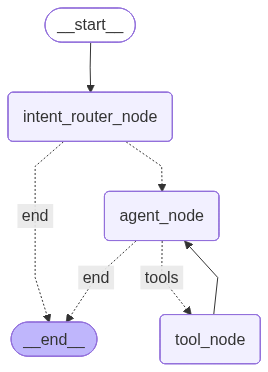

In [29]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
initial_state = {
    "messages": HumanMessage(content="Can I get a PC for my wife, a smart watch and phone charger for me and a pair of headphones for my son?")
}

In [31]:
result = graph.invoke(initial_state)

TypeError: can only concatenate list (not "HumanMessage") to list

In [ ]:
result

{'expanded_query': ['Desktop computer for wife',
  'Smart watch',
  'Phone charger',
  'Headphones for son'],
 'retrieved_context': ['- ID: B0BW95VZRB, rating: 4.4, description: QGOO USB Bluetooth Adapter for PC Bluetooth Dongle 5.3 EDR, Wireless Bluetooth Receiver for Desktop Computer Laptop Headphones Headset Keyboard Mouse Speakers Printer Windows 10/11(Olive Green) QGOO USB Bluetooth Adapter for PC Bluetooth Dongle 5.3 EDR, Wireless Bluetooth Receiver for Desktop Computer Laptop Headphones Headset Keyboard Mouse Speakers Printer Windows 10/11( olive green )\n- ID: B0B928M1FZ, rating: 3.8, description: Computer Desktop PC, Intel Core i5, TechMagnet Siwa 3, 16GB RAM, 1TB HDD, New MTG 22 Inch Monitor, Gaming Kit with Webcam, WiFi, Windows 10 Professional (Renewed) This desktop computer tower comes with RGB LED Light Siwa 3 on complete front Panel. Lighting can be changed with remote control and quickly adjust the lighting speed, and the mode with 385 color changing patterns. This comp

In [ ]:
print(result["answer"])

Yes, you can certainly purchase those items from our available products. Here are the details for the items you requested:

### PC for your wife
We have a couple of options for a desktop PC:
*   **TechMagnet Siwa 3 Desktop PC (ID: B0B928M1FZ)**
    *   **Processor:** Intel Core i5
    *   **RAM:** 16GB
    *   **Storage:** 1TB HDD
    *   **Monitor:** MTG 22 Inch Full HD (1920x1080) LED monitor (75Hz, IPS panel)
    *   **Included:** Gaming Kit with Webcam, RGB keyboard, wired gaming mouse, and headphones
    *   **Features:** RGB LED lighting with remote control, Windows 10 Professional
*   **Periphio Sub-Terra Gaming PC (ID: B097J4V43J)**
    *   **Processor:** Intel Core i5 6500
    *   **GPU:** GeForce GT 1030 (2GB GDDR5)
    *   **RAM:** 16GB DDR4
    *   **Storage:** 240GB SSD + 1TB HDD
    *   **Included:** RGB Mouse, RGB Keyboard, and Monitor
    *   **Features:** Built-in controllable RGB lighting, tempered glass side panel, Windows 10 Home

### Smart Watch for you
We have sev

In [ ]:
initial_state = {
    "initial_query": "Should I buy a ticket for the concert?"
}